## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health? 

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

## Question 1
Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 

In [2]:
import pandas as pd  
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression


df = pd.read_csv("golub.csv")
df.head()

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


In [3]:
mapper = {'allB':0,
          'allT':0,
          'aml':1}

y = df['cancer'].map(mapper) # target variable

## Question 2
Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 

OLS training MSE: 3.423875456688419e-30


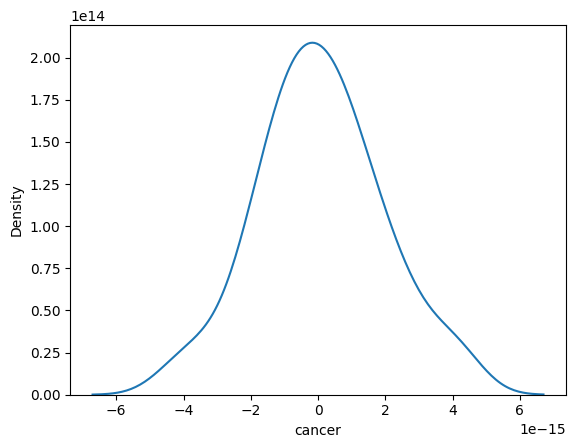

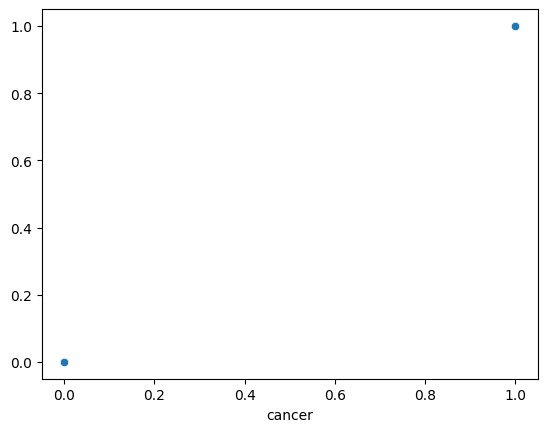

In [4]:
mse = lambda y, y_hat : np.mean((y-y_hat)**2)

X = df.drop(['Samples','BM.PB','Gender','Source','tissue.mf','cancer',], axis=1)
X.head()

model = LinearRegression()
reg = model.fit(X,y)

y_hat = reg.predict(X)
print(f'OLS training MSE: {mse(y,y_hat)}')

residuals = y_hat - y
sns.kdeplot(residuals)
plt.show()
residuals.describe()

sns.scatterplot(x=y, y=y_hat)
plt.show()

In [5]:
df.columns.to_list()

['Samples',
 'BM.PB',
 'Gender',
 'Source',
 'tissue.mf',
 'cancer',
 'AFFX-BioB-5_at',
 'AFFX-BioB-M_at',
 'AFFX-BioB-3_at',
 'AFFX-BioC-5_at',
 'AFFX-BioC-3_at',
 'AFFX-BioDn-5_at',
 'AFFX-BioDn-3_at',
 'AFFX-CreX-5_at',
 'AFFX-CreX-3_at',
 'AFFX-BioB-5_st',
 'AFFX-BioB-M_st',
 'AFFX-BioB-3_st',
 'AFFX-BioC-5_st',
 'AFFX-BioC-3_st',
 'AFFX-BioDn-5_st',
 'AFFX-BioDn-3_st',
 'AFFX-CreX-5_st',
 'AFFX-CreX-3_st',
 'hum_alu_at',
 'AFFX-DapX-5_at',
 'AFFX-DapX-M_at',
 'AFFX-DapX-3_at',
 'AFFX-LysX-5_at',
 'AFFX-LysX-M_at',
 'AFFX-LysX-3_at',
 'AFFX-PheX-5_at',
 'AFFX-PheX-M_at',
 'AFFX-PheX-3_at',
 'AFFX-ThrX-5_at',
 'AFFX-ThrX-M_at',
 'AFFX-ThrX-3_at',
 'AFFX-TrpnX-5_at',
 'AFFX-TrpnX-M_at',
 'AFFX-TrpnX-3_at',
 'AFFX-HUMISGF3A/M97935_5_at',
 'AFFX-HUMISGF3A/M97935_MA_at',
 'AFFX-HUMISGF3A/M97935_MB_at',
 'AFFX-HUMISGF3A/M97935_3_at',
 'AFFX-HUMRGE/M10098_5_at',
 'AFFX-HUMRGE/M10098_M_at',
 'AFFX-HUMRGE/M10098_3_at',
 'AFFX-HUMGAPDH/M33197_5_at',
 'AFFX-HUMGAPDH/M33197_M_at',
 'AFFX-HUMGA

## Question 3
Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

In [6]:
from sklearn.metrics import mean_squared_error

kfold = KFold(n_splits=10, shuffle=True, random_state=100)

scores = cross_val_score( # Conduct kfcv:
    model,X,y, # Model and data
    cv=kfold, # Folds
    scoring= "neg_mean_squared_error" # changed to from mean_squared_error 
    )
scores = -scores # change sign to get positive MSE values
# KFolds are like train/test splits, but done for multiple 'chunks'. The model is trained on the chunks, so we get multiple estimates on how well the model does for each chunk/fold.
# We are trying to estimate the mean-squared-error on data the model has not seen (out of sample error).
print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))

Fold scores: [0.02265367 0.04875751 0.06347474 0.06304086 0.09383082 0.08300696
 0.0207161  0.01969831 0.02087605 0.02271393]
Mean score: 0.04587689508852549
Median score: 0.03573571993995734
Std dev: 0.02703714498458801


## Question 4
Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 

In [7]:
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler


scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

alpha_grid = np.logspace(-4, -2, num=50)
model = LassoCV(cv=10, 
                alphas=alpha_grid,
                random_state=100)

model = model.fit(X_sc, y)

alpha_star = model.alpha_
index_star = np.argmin( np.mean(model.mse_path_,axis=1) )
coefs_star = Lasso(alpha=alpha_star, max_iter=10000).fit(X_sc,y).coef_

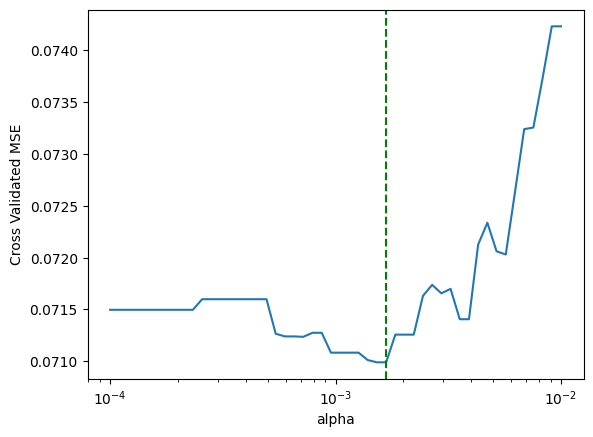

In [8]:
mse_mean = np.mean(model.mse_path_,axis=1)
sns.lineplot( x=model.alphas_, y=mse_mean)
plt.axvline(x=alpha_star, color='green', linestyle='--', 
            linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
plt.show()

In [15]:
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

alpha_grid = np.logspace(-4, -2, num=50)
lasso_cv = LassoCV(cv=10, alphas=alpha_grid, random_state=100, max_iter=10000)
lasso_cv.fit(X_sc, y)

alpha_star = lasso_cv.alpha_
mean_mse_path = np.mean(lasso_cv.mse_path_, axis=1)
index_star = np.argmin(mean_mse_path)

coefs = []
for alpha in lasso_cv.alphas_:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_sc, y)
    coefs.append(model.coef_)
coefs = np.array(coefs)

coefs_star = coefs[index_star]
selected_idx = np.nonzero(coefs_star)[0]
selected_genes = X.columns[selected_idx].tolist()

lasso_star = Lasso(alpha=alpha_star, max_iter=10000).fit(X_sc, y)
y_hat_lasso = lasso_star.predict(X_sc)

print(f'Optimal alpha: {alpha_star:.10f}')
print(f'Selected genes: {len(selected_genes)}')
print(f'Discarded genes: {X.shape[1] - len(selected_genes)}')
selected_genes


Optimal alpha: 0.0016768329
Selected genes: 70
Discarded genes: 7059


['AF000560_at',
 'AF006087_at',
 'D26579_at',
 'D29956_at',
 'D42043_at',
 'D50840_at',
 'D86982_at',
 'HG2161-HT2231_at',
 'J04101_at',
 'J04164_at',
 'L13278_at',
 'M17754_at',
 'M19507_at',
 'M20902_at',
 'M22960_at',
 'M23197_at',
 'M27819_at',
 'M27891_at',
 'M28713_at',
 'M31994_at',
 'M34344_at',
 'M63138_at',
 'M84526_at',
 'M95178_at',
 'M96326_rna1_at',
 'M98539_at',
 'U10868_at',
 'U14588_at',
 'U30828_at',
 'U34877_at',
 'U36621_cds2_at',
 'U46751_at',
 'U50136_rna1_at',
 'U51127_at',
 'U60062_at',
 'U82313_at',
 'U82759_at',
 'U89942_at',
 'X04143_at',
 'X14789_at',
 'X16706_at',
 'X53331_at',
 'X56741_at',
 'X63753_at',
 'X66533_at',
 'X69111_at',
 'X81479_at',
 'X83378_at',
 'X95735_at',
 'X96698_at',
 'Y07604_at',
 'Y07755_at',
 'Y10207_at',
 'Y12670_at',
 'M96843_at',
 'X58072_at',
 'AC002477_s_at',
 'L15326_s_at',
 'X57351_at',
 'U37055_rna1_s_at',
 'X07438_s_at',
 'M13690_s_at',
 'M26708_s_at',
 'M84371_rna1_s_at',
 'X12876_s_at',
 'U26312_s_at',
 'X85116_rna1_s_at',

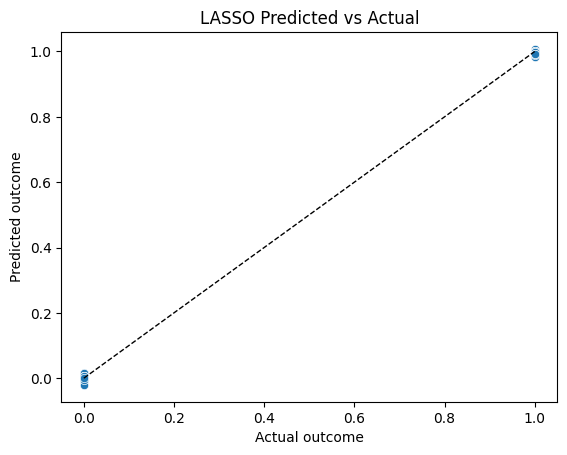

LASSO training MSE: 4.64279e-05


In [16]:
sns.scatterplot(x=y, y=y_hat_lasso)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
plt.title('LASSO Predicted vs Actual')
plt.xlabel('Actual outcome')
plt.ylabel('Predicted outcome')
plt.show()

print(f'LASSO training MSE: {mse(y, y_hat_lasso):.6g}')

- the y values are binary (0 or 1) because it represents two outcome classes, so there is a lot of overplotting. The actual values appear as vertical clusters in the scatterplot, while the LASSO model produces continuous predictions 

## Question 5
Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

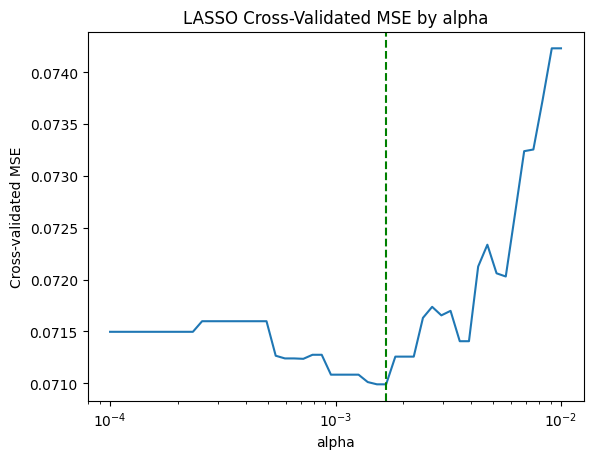

In [17]:
sns.lineplot(x=lasso_cv.alphas_, y=mean_mse_path)
plt.axvline(alpha_star, color='green', linestyle='--', linewidth=1.5)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.title('LASSO Cross-Validated MSE by alpha')
plt.show()

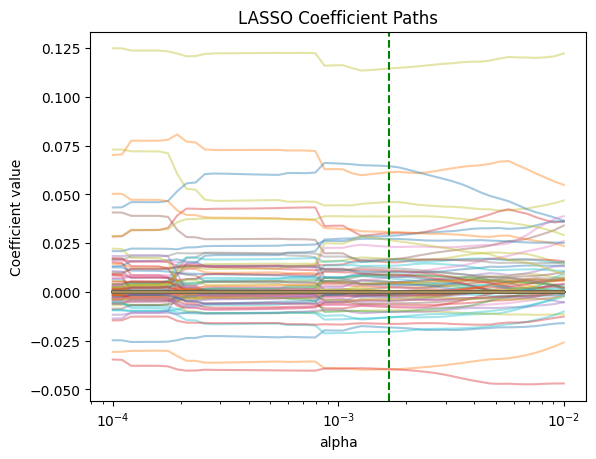

In [18]:
for i in range(coefs.shape[1]):
    plt.plot(lasso_cv.alphas_, coefs[:, i], alpha=0.4)
plt.xscale('log')
plt.axvline(alpha_star, color='green', linestyle='--')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths')
plt.show()

- This shows underfitting on the left side of the plot (shrinkage) and overfitting on the right side of the plot (too many coefficients). 
- The minimum error is at around 0.0006551

## Question 6
Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

The model achieves perfect performance on the training data because the setting is high-dimensional, with far more predictors than observations. This allows the model to effectively memorize the training sample, driving the training error to zero. However, this flexibility also makes the estimated coefficients highly sensitive to noise.

LASSO improves predictive performance by shrinking coefficients and forcing many of them to exactly zero. While this introduces a small increase in bias, it substantially reduces variance. In this dataset, that trade-off is advantageous because only a limited subset of genes appears to contain most of the information needed to distinguish ALL from AML.

## Question 7
Why do regularization methods lend themselves to scenarios like precision health? 

Humans have roughly 22,000 to 25,000 genes, and these genes interact in complex ways to shape biological outcomes. When we include two-way, three-way, and higher-order interactions among genes, the feature space grows rapidly, which is often far beyond the size of any available high-quality genomics dataset.

In these high-dimensional settings, methods like LASSO help by narrowing the model to a smaller, more relevant subset of genes and interactions. This makes the results more interpretable and far more practical for medical testing and genetics research.

## Question 8
 What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

These results are purely predictive and do not establish causality. We do not have a causal understanding of how changing any single gene would affect outcomes, since gene expression reflects a complex system of simultaneously interacting factors. In practice, we cannot simply "flip" a gene without fundamentally altering the organism.

As a result, the genes identified by the model may be strong predictors but not necessarily part of a true causal pathway. Because we are observing correlations rather than causation, we should be cautious about using these findings to justify surgical or pharmaceutical interventions that could risk harming a patient's health.